## Import libraries and packages







In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from collections import Counter

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.svm import SVC

In [ ]:
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

# load data set

In [ ]:
data = pd.read_csv('Dataset.csv')
print(data.shape)
data.head()

(252000, 13)


,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


Being more familiar with unique values each of these non-numerical variables hold

In [ ]:
print(set(data['Married/Single'].values.tolist()))
print(set(data['House_Ownership'].values.tolist()))
print(set(data['Car_Ownership'].values.tolist()))
print(set(data['Profession'].values.tolist()))
print(set(data['CITY'].values.tolist()))
print(set(data['STATE'].values.tolist()))

{'single', 'married'}
{'norent_noown', 'rented', 'owned'}
{'no', 'yes'}
{'Architect', 'Artist', 'Librarian', 'Technician', 'Financial_Analyst', 'Surveyor', 'Computer_hardware_engineer', 'Chef', 'Petroleum_Engineer', 'Drafter', 'Scientist', 'Lawyer', 'Hotel_Manager', 'Design_Engineer', 'Microbiologist', 'Air_traffic_controller', 'Fashion_Designer', 'Physician', 'Politician', 'Firefighter', 'Psychologist', 'Magistrate', 'Technical_writer', 'Graphic_Designer', 'Statistician', 'Designer', 'Chemical_engineer', 'Industrial_Engineer', 'Army_officer', 'Computer_operator', 'Biomedical_Engineer', 'Flight_attendant', 'Economist', 'Dentist', 'Geologist', 'Web_designer', 'Police_officer', 'Secretary', 'Civil_servant', 'Consultant', 'Chartered_Accountant', 'Aviator', 'Civil_engineer', 'Surgeon', 'Software_Developer', 'Engineer', 'Comedian', 'Technology_specialist', 'Analyst', 'Official', 'Mechanical_engineer'}
{'Amroha', 'Bhagalpur', 'Chapra', 'Ramgarh', 'Akola', 'Secunderabad', 'Surendranagar_Dudhr

# Feature Selection

Firt criteria for feature selection is number of unique. by this criteria we conclude that 'city' and 'state' contain more than 20 unique values, which are irrelevant to loan allocation and should be removed.
Besides,In this data "ID" is one such column which is useless to us because it does not affect the approval or rejection of a loan. Hence, we will remove "ID" from the data.

In [ ]:
data.nunique()

Id                   252000
Income                41920
Age                      59
Experience               21
Married/Single            2
House_Ownership           3
Car_Ownership             2
Profession               51
CITY                    317
STATE                    29
CURRENT_JOB_YRS          15
CURRENT_HOUSE_YRS         5
Risk_Flag                 2
dtype: int64

In [ ]:
data = data.drop(['Id','CITY','STATE'],axis=1)

Also we check correlation matrix for remaining features to remove pairs of features that have a high correlation coefficient (close to 1 or -1). High positive correlation indicates that the features are strongly related and may provide redundant information. High negative correlation suggests that the features are inversely related and can potentially be used as complementary information.
But in this dataset correlation coefficient are not that high and because our dataset is not distributed, correlation coefficient can't work well.

**because, corr() just accept numbers we should encode categorical features in this part.** so we introduce a new variable which contains data and we encode this variable for correlation matrix.

In [ ]:
data_corr = data


# Create a LabelEncoder object
label_encoder_Material = LabelEncoder()
label_encoder_Car = LabelEncoder()
label_encoder_House = LabelEncoder()
label_encoder_Profession = LabelEncoder()

# Encode the 'Married/Single' feature
data_corr['Married/Single'] = label_encoder_Material.fit_transform(data_corr['Married/Single'])
data_corr['Car_Ownership'] = label_encoder_Car.fit_transform(data_corr['Car_Ownership'])
data_corr['House_Ownership'] = label_encoder_House.fit_transform(data_corr['House_Ownership'])
data_corr['Profession'] = label_encoder_Profession.fit_transform(data_corr['Profession'])



<Axes: >

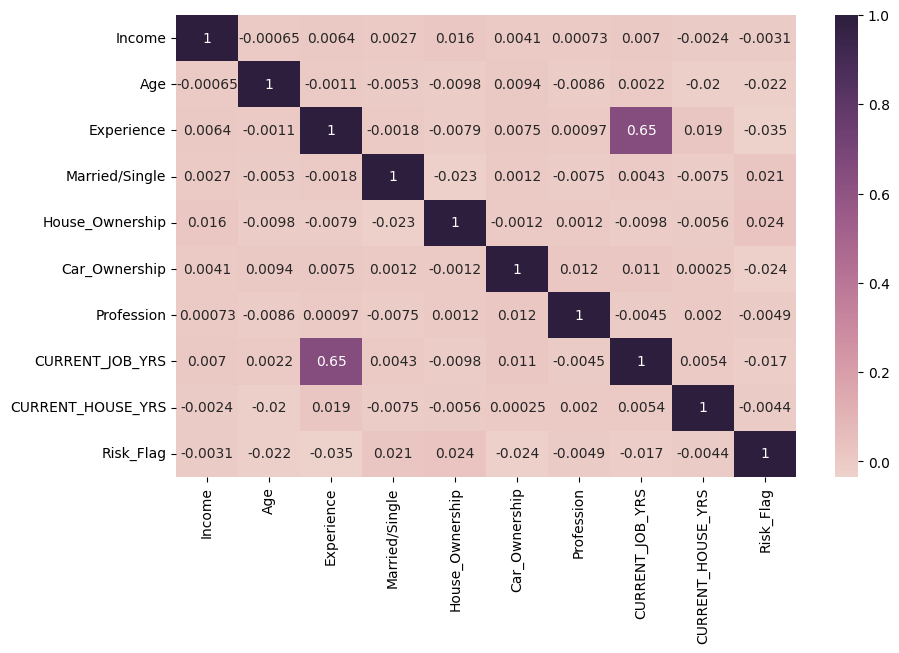

In [ ]:
cor = data_corr.corr()
plt.figure(figsize=(10,6))
sns.heatmap(cor,cmap=sns.cubehelix_palette(as_cmap=True),annot=True)

# train-test-split

In [ ]:
y = data['Risk_Flag']
X = data.drop(['Risk_Flag'],axis=1)

By using stratify parameter, we can ensure that label distributions are uniform in test set and train set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0,stratify=y)

we can show these uniform distribution by bar charts.

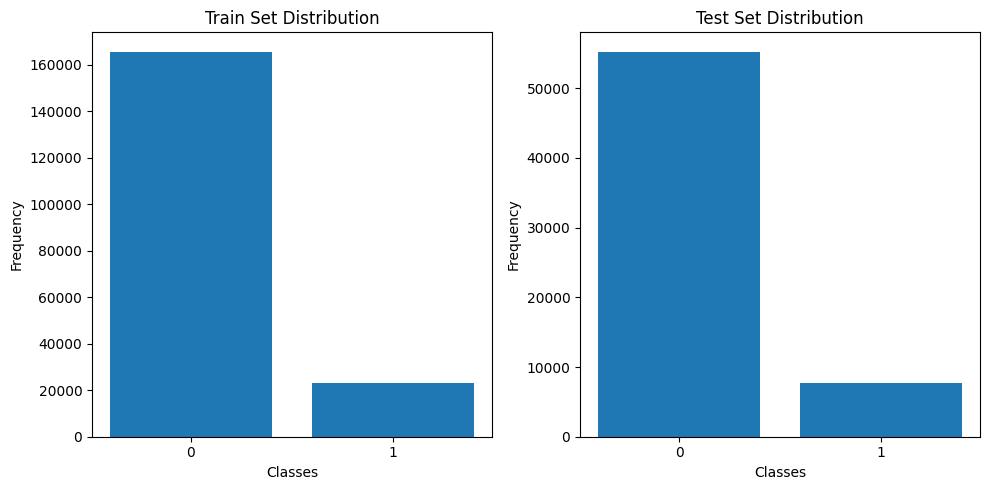

In [ ]:
# Calculate the class/category frequencies in the train set
train_classes, train_counts = np.unique(y_train, return_counts=True)

# Calculate the class/category frequencies in the test set
test_classes, test_counts = np.unique(y_test, return_counts=True)

# Plot the distribution of the target variable in the train set
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(train_classes, train_counts)
plt.xlabel('Classes')
plt.ylabel('Frequency')
plt.title('Train Set Distribution')
plt.xticks(range(len(train_classes)), train_classes)

# Plot the distribution of the target variable in the test set
plt.subplot(1, 2, 2)
plt.bar(test_classes, test_counts)
plt.xlabel('Classes')
plt.ylabel('Frequency')
plt.title('Test Set Distribution')
plt.xticks(range(len(test_classes)), test_classes)

plt.tight_layout()
plt.show()

# processing features

Null data analysis

In [ ]:
total_null = data.isnull().sum().sort_values(ascending=False)
total_null.head(13)

Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64

Encoding

In [ ]:
# Create separate LabelEncoder objects for each categorical column
label_encoder_marital = LabelEncoder()
label_encoder_car = LabelEncoder()
label_encoder_house = LabelEncoder()
label_encoder_profession = LabelEncoder()

# Encoding train set
X_train['Married/Single'] = label_encoder_marital.fit_transform(X_train['Married/Single'])
X_train['Car_Ownership'] = label_encoder_car.fit_transform(X_train['Car_Ownership'])
X_train['House_Ownership'] = label_encoder_house.fit_transform(X_train['House_Ownership'])
X_train['Profession'] = label_encoder_profession.fit_transform(X_train['Profession'])

# Encoding test set
X_test['Married/Single'] = label_encoder_marital.transform(X_test['Married/Single'])
X_test['Car_Ownership'] = label_encoder_car.transform(X_test['Car_Ownership'])
X_test['House_Ownership'] = label_encoder_house.transform(X_test['House_Ownership'])
X_test['Profession'] = label_encoder_profession.transform(X_test['Profession'])

In [ ]:
first_rows = X_train[:0]  # Retrieve the first 5 rows
print(first_rows)

Empty DataFrame
Columns: [Income, Age, Experience, Married/Single, House_Ownership, Car_Ownership, Profession, CURRENT_JOB_YRS, CURRENT_HOUSE_YRS]
Index: []


Normalization of train set by using StandardScaler. Be aware of that StandardScaler using average and variance of train set to Standardize features by removing the mean and scaling to unit variance.
It should be noted that for standardization of test set we should use average and variance of train set.
Besides, I check both standardization(StandardScaler) and normalization(MinMaxScaler), but there was no big differences for this data set.

In [ ]:
# Choose either standardization or Normalization

# Choose between standardization and MinMAx normalization
PredictorScaler=StandardScaler()
#PredictorScaler=MinMaxScaler()

# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X_train)

# Generating the standardized values of X_train
X_train=PredictorScalerFit.transform(X_train)
# Generating the standardized values of X_test by average and variance of train set
X_test=PredictorScalerFit.transform(X_test)



# Label Distribution

At first, plotting a bar chart of label distribution can help us to analysis imbalancing of labels.

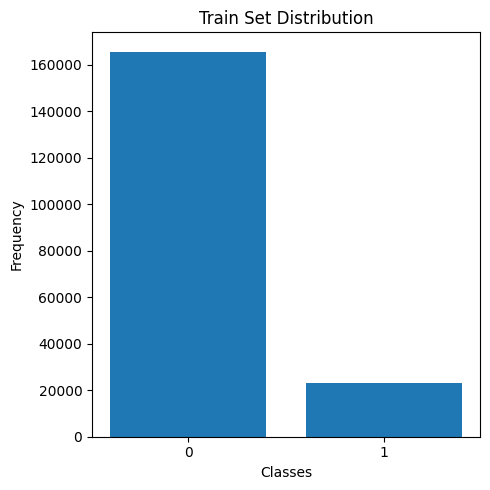

In [ ]:
# Calculate the class/category frequencies in the train set
train_classes, train_counts = np.unique(y_train, return_counts=True)

# Plot the distribution of the target variable in the train set
plt.figure(figsize=(5, 5))
plt.bar(train_classes, train_counts)
plt.xlabel('Classes')
plt.ylabel('Frequency')
plt.title('Train Set Distribution')
plt.xticks(range(len(train_classes)), train_classes)


plt.tight_layout()
plt.show()

Now we use RandomUnderSampler to balance label distribution. Also I checked RandomOverSampler, but RandomOverSampler increase numbers of samples and it slows speed of SVM.fit.

In [ ]:

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 23247, 1: 23247})


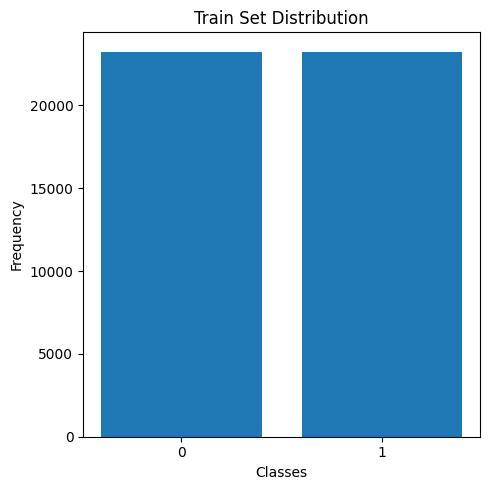

In [ ]:
# Calculate the class/category frequencies in the train set
X_res_classes, X_res_counts = np.unique(y_res, return_counts=True)

# Plot the distribution of the target variable in the train set
plt.figure(figsize=(5, 5))
plt.bar(X_res_classes, X_res_counts)
plt.xlabel('Classes')
plt.ylabel('Frequency')
plt.title('Train Set Distribution')
plt.xticks(range(len(X_res_classes)), X_res_classes)


plt.tight_layout()
plt.show()

# train and test_Decision tree

In [ ]:
# Gini
tree = DecisionTreeClassifier( random_state=0)
tree.fit(X_res, y_res)
print("Accuracy on training set: {:.3f}".format(tree.score(X_res, y_res)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))
export_graphviz(tree, out_file="tree.dot", class_names=["1", "0"],
 feature_names= first_rows.columns, impurity=False, filled=True)


Accuracy on training set: 0.957
Accuracy on test set: 0.848


Confusion matrix

In [ ]:
y_pred_tree = tree.predict(X_test)
confusion_tree = confusion_matrix(y_test, y_pred_tree)
print("Confusion matrix:\n{}".format(confusion_tree))

print(classification_report(y_test, y_pred_tree,
 target_names=["1", "0"]))

Confusion matrix:
[[46596  8655]
 [  918  6831]]
              precision    recall  f1-score   support

           1       0.98      0.84      0.91     55251
           0       0.44      0.88      0.59      7749

    accuracy                           0.85     63000
   macro avg       0.71      0.86      0.75     63000
weighted avg       0.91      0.85      0.87     63000



# train and test_SVM

In [ ]:
svm = SVC(kernel='linear')

In [ ]:
svm.fit(X_res, y_res)

SVC(kernel='linear')

In [ ]:
y_pred_svm = svm.predict(X_test)

In [ ]:
print("Accuracy on training set: {:.3f}".format(svm.score(X_res, y_res)))
print("Accuracy on test set: {:.3f}".format(svm.score(X_test, y_test)))

Accuracy on training set: 0.539
Accuracy on test set: 0.473


In [ ]:
confusion_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion matrix:\n{}".format(confusion_svm))

print(classification_report(y_test, y_pred_svm,
 target_names=["1", "0"]))

Confusion matrix:
[[25060 30191]
 [ 3013  4736]]
              precision    recall  f1-score   support

           1       0.89      0.45      0.60     55251
           0       0.14      0.61      0.22      7749

    accuracy                           0.47     63000
   macro avg       0.51      0.53      0.41     63000
weighted avg       0.80      0.47      0.55     63000



# Setting hyper parameters

desicion_tree

In [ ]:
tree1 = DecisionTreeClassifier()
param_grid = {'criterion' : ['gini','entropy','log_loss'],'max_depth' : range(4,63)}
grid_search = GridSearchCV((tree1), param_grid, cv=5)
grid_search.fit(X_res, y_res)
print("Test set score: {:.2f}".format(grid_search.score(X_test, y_test)))
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

Test set score: 0.85
Best parameters: {'criterion': 'gini', 'max_depth': 51}
Best cross-validation score: 0.86


In [ ]:
y_pred_tree1 = grid_search.predict(X_test)
confusion_tree1 = confusion_matrix(y_test, y_pred_tree1)
print("Confusion matrix:\n{}".format(confusion_tree1))

print(classification_report(y_test, y_pred_tree1,
 target_names=["1", "0"]))

Confusion matrix:
[[46546  8705]
 [  916  6833]]
              precision    recall  f1-score   support

           1       0.98      0.84      0.91     55251
           0       0.44      0.88      0.59      7749

    accuracy                           0.85     63000
   macro avg       0.71      0.86      0.75     63000
weighted avg       0.91      0.85      0.87     63000



In [ ]:
param_grid = {'C' : range(1,5)}
grid_search_svm = GridSearchCV((svm), param_grid, cv=5)
grid_search_svm.fit(X_res, y_res)
print("Test set score: {:.2f}".format(grid_search_svm.score(X_test, y_test)))
print("Best parameters: {}".format(grid_search_svm.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search_svm.best_score_))

In [ ]:
y_pred_svm = grid_search_svm.predict(X_test)
confusion_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion matrix:\n{}".format(confusion_svm))

print(classification_report(y_test, y_pred_svm,
 target_names=["1", "0"]))

Confusion matrix:
[[30103 25148]
 [ 3813  3936]]
              precision    recall  f1-score   support

           1       0.89      0.54      0.68     55251
           0       0.14      0.51      0.21      7749

    accuracy                           0.54     63000
   macro avg       0.51      0.53      0.44     63000
weighted avg       0.80      0.54      0.62     63000



# part 4

While SVMs often perform quite well, they are
very sensitive to the settings of the parameters and to the scaling of the data.In par‐
ticular, they require all the features to vary on a similar scale

One way to resolve this problem is by rescaling each feature so that they are all
approximately on the same scale. A common rescaling method for kernel SVMs is to
scale the data such that all features are between 0 and 1. We will see how to do this
using the MinMaxScaler preprocessing method

In [ ]:
sample1 = []
count = 0

for input, prediction, prediction2, label in zip(X_test, y_pred_tree1, y_pred_svm, y_test):
    if prediction == label and prediction2 != label:
        row = np.concatenate((input, [prediction, prediction2, label]))
        sample1.append(row)
        count += 1
        if count == 10:
            break

sample1 = np.array(sample1)
header = ['Income', 'Age', 'Experience', 'Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession',
          'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'y_pred_tree', 'y_pred_svm', 'y_test']

misclassified_df = pd.DataFrame(sample1, columns=header)

print(misclassified_df.to_string(index=False, max_rows=None))

   Income       Age  Experience  Married/Single  House_Ownership  Car_Ownership  Profession  CURRENT_JOB_YRS  CURRENT_HOUSE_YRS  y_pred_tree  y_pred_svm  y_test
-0.598008 -1.518047   -0.181334        0.336976         0.276533      -0.657211    0.592611         0.180619           0.000518          0.0         1.0     0.0
-1.638274 -0.815463   -0.014608        0.336976         0.276533      -0.657211   -0.832208         1.003164          -1.428681          0.0         1.0     0.0
-0.854258 -0.288525   -0.681510        0.336976         0.276533       1.521581   -0.153723        -0.916107          -1.428681          0.0         1.0     0.0
-1.222000  0.296962   -0.514784        0.336976         0.276533      -0.657211   -1.442844        -0.367744           1.429717          0.0         1.0     0.0
-1.054648  1.526484   -0.014608        0.336976        -2.279824      -0.657211    1.678186        -0.367744          -1.428681          1.0         0.0     1.0
-0.685690  1.058095   -0.848235   

In [ ]:
sample1 = []
count = 0

for input, prediction, prediction2, label in zip(X_test, y_pred_tree1, y_pred_svm, y_test):
    if prediction != label and prediction2 == label:
        row = np.concatenate((input, [prediction, prediction2, label]))
        sample1.append(row)
        count += 1
        if count == 10:
            break

sample1 = np.array(sample1)
header = ['Income', 'Age', 'Experience', 'Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession',
          'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'y_pred_tree', 'y_pred_svm', 'y_test']

misclassified_df = pd.DataFrame(sample1, columns=header)

print(misclassified_df.to_string(index=False, max_rows=None))


   Income       Age  Experience  Married/Single  House_Ownership  Car_Ownership  Profession  CURRENT_JOB_YRS  CURRENT_HOUSE_YRS  y_pred_tree  y_pred_svm  y_test
-0.384440  0.472608    0.985744       -2.967569         0.276533       1.521581    0.864005        -0.641926          -0.714081          1.0         0.0     0.0
-0.340817  0.355511    0.485568       -2.967569         0.276533      -0.657211   -1.442844        -0.093563           0.715117          1.0         0.0     0.0
 1.168394 -0.874012    1.485919        0.336976         0.276533      -0.657211   -0.018026         1.825708           0.000518          1.0         0.0     0.0
-1.169146  1.233741    0.985744        0.336976         0.276533      -0.657211    0.389065         1.277345           1.429717          1.0         0.0     0.0
 0.784667  0.472608    1.152469        0.336976        -2.279824      -0.657211    0.592611         0.728982           1.429717          1.0         0.0     0.0
-1.348020  0.765351    1.652645   

In [ ]:
sample1 = []
count = 0

for input, prediction, prediction2, label in zip(X_test, y_pred_tree1, y_pred_svm, y_test):
    if prediction == label and prediction2 == label:
        row = np.concatenate((input, [prediction, prediction2, label]))
        sample1.append(row)
        count += 1
        if count == 10:
            break

sample1 = np.array(sample1)
header = ['Income', 'Age', 'Experience', 'Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession',
          'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'y_pred_tree', 'y_pred_svm', 'y_test']

misclassified_df = pd.DataFrame(sample1, columns=header)

print(misclassified_df.to_string(index=False, max_rows=None))

   Income       Age  Experience  Married/Single  House_Ownership  Car_Ownership  Profession  CURRENT_JOB_YRS  CURRENT_HOUSE_YRS  y_pred_tree  y_pred_svm  y_test
-0.423263  0.414059   -0.348059        0.336976         0.276533      -0.657211    0.117671         0.454800           1.429717          1.0         1.0     1.0
 1.509977 -0.112879    0.318842        0.336976         0.276533       1.521581   -0.153723         1.551527          -1.428681          0.0         0.0     0.0
-1.009366  1.233741   -0.514784       -2.967569         0.276533      -0.657211    0.592611        -0.916107           0.000518          0.0         0.0     0.0
-0.871411 -0.112879    1.652645        0.336976         0.276533      -0.657211   -1.171450        -0.367744          -1.428681          0.0         0.0     0.0
-0.436204 -0.698366    1.485919        0.336976         0.276533      -0.657211   -0.832208         1.003164           0.715117          0.0         0.0     0.0
 1.501252 -1.459498    1.652645   

In [ ]:
sample1 = []
count = 0

for input, prediction, prediction2, label in zip(X_test, y_pred_tree1, y_pred_svm, y_test):
    if prediction != label and prediction2 != label:
        row = np.concatenate((input, [prediction, prediction2, label]))
        sample1.append(row)
        count += 1
        if count == 10:
            break

sample1 = np.array(sample1)
header = ['Income', 'Age', 'Experience', 'Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession',
          'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'y_pred_tree', 'y_pred_svm', 'y_test']

misclassified_df = pd.DataFrame(sample1, columns=header)

print(misclassified_df.to_string(index=False, max_rows=None))

   Income       Age  Experience  Married/Single  House_Ownership  Car_Ownership  Profession  CURRENT_JOB_YRS  CURRENT_HOUSE_YRS  y_pred_tree  y_pred_svm  y_test
-0.991291 -0.698366   -0.681510       -2.967569         0.276533      -0.657211   -0.764359        -0.093563           0.715117          1.0         1.0     0.0
 0.461927 -1.400950    1.152469        0.336976         0.276533      -0.657211   -1.510693         1.551527          -0.714081          1.0         1.0     0.0
-1.152647 -1.283852   -0.514784        0.336976         0.276533      -0.657211    1.610338         0.180619          -1.428681          1.0         1.0     0.0
 1.019723 -0.288525    0.152117        0.336976         0.276533      -0.657211   -0.560814         1.277345           0.715117          1.0         1.0     0.0
-0.744272  0.414059   -1.181685        0.336976         0.276533      -0.657211   -1.374996        -0.916107           0.715117          1.0         1.0     0.0
-0.992311  1.175192   -0.848235   